# 71 - 既存Embeddingモデルによる画像→テキスト近似

## 概要
既存の対照学習モデル（SigLIP 2, CLIP-L）だけで、画像の内容をテキストとしてどこまで表現できるかを検証する。
対照学習モデルはテキスト生成能力を持たないため、「候補テキストプールからの検索」で近似する。

## 手法
1. **Zero-shot 分類による擬似キャプション**: 階層的ラベル（シーン、オブジェクト、属性）のTop-K組み合わせ
2. **テンプレートベース構成**: タグを組み合わせて自然文に変換
3. **候補文プール検索**: 事前定義した候補キャプションから最も類似度の高いものを選択

## 評価
- **Self-Retrieval Score**: 生成した擬似キャプションのembeddingと元画像embeddingのコサイン類似度
- **カテゴリ一貫性**: 同一カテゴリの画像に対する擬似キャプションの類似性
- **視覚的確認**: 各カテゴリのサンプル画像と擬似キャプションの対応

## 使用モデル
- SigLIP 2 Large (`google/siglip2-large-patch16-256`) — 最良モデル（JA MRR 1.000）
- CLIP-L (`openai/clip-vit-large-patch14`) — ベースライン比較用

## 前提
- Notebook 61-67 で SigLIP 2 の画像埋め込みが DuckDB に保存済みであること

In [1]:
import json
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

from image_vector_poc import SigLIP2Embedder
from image_vector_poc.tagging.zero_shot import ZeroShotTagger

## 1. 設定とデータ読み込み

In [2]:
DB_PATH = Path("../data/images.duckdb")
MODEL_NAME = "google/siglip2-large-patch16-256"
BATCH_SIZE = 16

# 画像カタログの読み込み
conn = duckdb.connect(str(DB_PATH), read_only=True)

catalog_df = conn.execute("""
    SELECT id, file_path, category, file_name
    FROM image_catalog
    ORDER BY id
""").fetchdf()

print(f"Total images: {len(catalog_df)}")
print(f"\nCategories:")
for cat, count in catalog_df['category'].value_counts().items():
    print(f"  {cat}: {count}")

Total images: 378

Categories:
  EuroPython2025: 129
  PyConJP2025: 77
  PyConJP2025-PreCampHiroshima: 57
  KashiwaVillagePark2026: 56
  TokyoNight202505: 49
  terada: 10


In [3]:
# SigLIP 2 Large の埋め込みを読み込み
embeddings_df = conn.execute("""
    SELECT c.id, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [MODEL_NAME]).fetchdf()
conn.close()

print(f"Loaded {len(embeddings_df)} embeddings")

if len(embeddings_df) == 0:
    raise ValueError(f"No embeddings found for {MODEL_NAME}. Please run notebook 67 first.")

image_embeddings = np.array(embeddings_df['embedding'].tolist(), dtype=np.float32)
print(f"Embeddings shape: {image_embeddings.shape}")

# L2正規化
norms = np.linalg.norm(image_embeddings, axis=1, keepdims=True)
image_embeddings_norm = image_embeddings / np.clip(norms, 1e-8, None)

Loaded 378 embeddings
Embeddings shape: (378, 1024)


## 2. モデルの読み込み

In [4]:
embedder = SigLIP2Embedder(model_name=MODEL_NAME, device="cuda")
print(f"Model loaded: {embedder.model_name}")
print(f"Embedding dimension: {embedder.embedding_dim}")

Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model loaded: google/siglip2-large-patch16-256
Embedding dimension: 1024


## 3. 手法1: Zero-shot 分類による擬似キャプション

階層的なラベルセットを定義し、`ZeroShotTagger` で各カテゴリからTop-Kタグを取得する。
取得したタグを組み合わせて擬似キャプションを構成する。

In [5]:
# 階層的ラベルの定義

# シーン（場所・状況）
scene_labels_en = [
    "a park with trees", "a city at night", "a conference hall",
    "a portrait studio", "an outdoor garden", "a street at night",
    "a workshop room", "an auditorium", "a nature trail",
    "a meeting room", "a stage with a speaker", "a riverside",
    "a forest", "a building exterior at night", "a banquet hall",
]

scene_labels_ja = [
    "公園", "夜の都市", "カンファレンスホール",
    "ポートレートスタジオ", "屋外の庭園", "夜の街路",
    "ワークショップ会場", "講堂", "自然遊歩道",
    "会議室", "登壇者のいるステージ", "川辺",
    "森林", "夜の建物外観", "宴会場",
]

# オブジェクト
object_labels_en = [
    "trees and plants", "buildings and skyscrapers", "people in audience",
    "a person's face", "presentation slides", "city lights",
    "a podium", "laptops and computers", "flowers",
    "a bridge", "neon signs", "chairs and tables",
    "water and pond", "a microphone", "name badges",
]

object_labels_ja = [
    "木々と植物", "ビルと高層建築", "聴衆",
    "人の顔", "プレゼンテーションスライド", "街の灯り",
    "演台", "ノートPCとコンピュータ", "花",
    "橋", "ネオンサイン", "椅子とテーブル",
    "水と池", "マイク", "名札",
]

# 属性（環境・雰囲気）
attribute_labels_en = [
    "outdoor daytime", "outdoor nighttime", "indoor",
    "bright and sunny", "dark and moody", "crowded",
    "calm and peaceful", "colorful illumination", "professional setting",
]

attribute_labels_ja = [
    "屋外・昼間", "屋外・夜間", "屋内",
    "明るく晴れた", "暗くムーディーな", "混雑した",
    "穏やかで静かな", "カラフルなイルミネーション", "プロフェッショナルな環境",
]

print(f"Scene labels: {len(scene_labels_en)} EN, {len(scene_labels_ja)} JA")
print(f"Object labels: {len(object_labels_en)} EN, {len(object_labels_ja)} JA")
print(f"Attribute labels: {len(attribute_labels_en)} EN, {len(attribute_labels_ja)} JA")

Scene labels: 15 EN, 15 JA
Object labels: 15 EN, 15 JA
Attribute labels: 9 EN, 9 JA


In [6]:
# ZeroShotTagger で各カテゴリのタグを取得

# シーン分類
scene_tagger_en = ZeroShotTagger(embedder, scene_labels_en, template="This is a photo of {label}.")
scene_tagger_ja = ZeroShotTagger(embedder, scene_labels_ja, template="{label}の写真。")

# オブジェクト分類
object_tagger_en = ZeroShotTagger(embedder, object_labels_en, template="This photo contains {label}.")
object_tagger_ja = ZeroShotTagger(embedder, object_labels_ja, template="{label}が写っている写真。")

# 属性分類
attr_tagger_en = ZeroShotTagger(embedder, attribute_labels_en, template="This is an {label} scene.")
attr_tagger_ja = ZeroShotTagger(embedder, attribute_labels_ja, template="{label}シーン。")

print("Taggers initialized.")

Taggers initialized.


In [7]:
# サンプル画像でタグ付け結果を確認
sample_indices = []
for cat in catalog_df['category'].unique():
    cat_indices = catalog_df[catalog_df['category'] == cat].index.tolist()
    sample_indices.extend(cat_indices[:2])  # 各カテゴリ2枚

print(f"Sample images: {len(sample_indices)}")
print()

for idx in sample_indices:
    row = catalog_df.iloc[idx]
    img = Image.open(row['file_path']).convert('RGB')
    
    scene_tags = scene_tagger_en.tag(img, top_k=2)
    object_tags = object_tagger_en.tag(img, top_k=3)
    attr_tags = attr_tagger_en.tag(img, top_k=2)
    
    print(f"[{row['category']}] {row['file_name']}")
    print(f"  Scene:  {', '.join(f'{t}({s:.3f})' for t, s in scene_tags)}")
    print(f"  Object: {', '.join(f'{t}({s:.3f})' for t, s in object_tags)}")
    print(f"  Attr:   {', '.join(f'{t}({s:.3f})' for t, s in attr_tags)}")
    print()

Sample images: 12



[terada] terada-202205-pyconjp-4-3-900.jpg
  Scene:  a portrait studio(0.096), a city at night(0.053)
  Object: a person's face(0.124), name badges(0.102), presentation slides(0.082)
  Attr:   professional setting(0.070), crowded(0.058)

[terada] terada-uspycon2019-up.jpg
  Scene:  a stage with a speaker(0.116), a portrait studio(0.064)
  Object: a podium(0.150), a person's face(0.118), people in audience(0.108)
  Attr:   crowded(0.069), bright and sunny(0.066)



[PyConJP2025] 2025-09-27 18.17.03.jpg
  Scene:  a stage with a speaker(0.158), a conference hall(0.127)
  Object: a podium(0.160), presentation slides(0.138), people in audience(0.110)
  Attr:   professional setting(0.086), indoor(0.084)



[PyConJP2025] 2025-09-25 20.54.50.jpg
  Scene:  a workshop room(0.086), a banquet hall(0.077)
  Object: people in audience(0.108), a person's face(0.077), a podium(0.075)
  Attr:   crowded(0.151), indoor(0.115)



[EuroPython2025] 2025-07-16 17.23.43.jpg
  Scene:  a stage with a speaker(0.099), a conference hall(0.085)
  Object: presentation slides(0.131), people in audience(0.131), name badges(0.108)
  Attr:   professional setting(0.065), crowded(0.061)



...

[PyConJP2025-PreCampHiroshima] 2025-06-07 16.30.24.jpg
  Scene:  a banquet hall(0.191), a meeting room(0.189)
  Object: chairs and tables(0.139), a podium(0.118), presentation slides(0.094)
  Attr:   indoor(0.132), professional setting(0.129)



[TokyoNight202505] 2025-04-27 20.41.48.jpg
  Scene:  a building exterior at night(0.128), a city at night(0.127)
  Object: city lights(0.124), buildings and skyscrapers(0.092), neon signs(0.091)
  Attr:   colorful illumination(0.105), outdoor nighttime(0.102)



[TokyoNight202505] 2025-04-27 20.36.03.jpg
  Scene:  a city at night(0.150), a building exterior at night(0.130)
  Object: city lights(0.146), trees and plants(0.101), neon signs(0.100)
  Attr:   outdoor nighttime(0.142), colorful illumination(0.119)



[KashiwaVillagePark2026] 2026-01-03 13.31.08.jpg
  Scene:  a riverside(0.063), an outdoor garden(0.043)
  Object: water and pond(0.108), flowers(0.038), presentation slides(0.026)
  Attr:   calm and peaceful(0.073), bright and sunny(0.057)



[KashiwaVillagePark2026] 2026-01-03 13.13.19.jpg
  Scene:  a riverside(0.086), a forest(0.031)
  Object: water and pond(0.116), flowers(0.048), a bridge(0.045)
  Attr:   calm and peaceful(0.093), dark and moody(0.077)



In [8]:
# 全画像に対して擬似キャプションを生成

def generate_pseudo_caption_en(image: Image.Image) -> str:
    """英語の擬似キャプションを生成する。"""
    scene_tags = scene_tagger_en.tag(image, top_k=1)
    object_tags = object_tagger_en.tag(image, top_k=2)
    attr_tags = attr_tagger_en.tag(image, top_k=1)
    
    scene = scene_tags[0][0] if scene_tags else "a scene"
    objects = " and ".join(t for t, _ in object_tags) if object_tags else "objects"
    attr = attr_tags[0][0] if attr_tags else ""
    
    caption = f"A photo of {scene} with {objects}"
    if attr:
        caption += f", {attr}"
    return caption


def generate_pseudo_caption_ja(image: Image.Image) -> str:
    """日本語の擬似キャプションを生成する。"""
    scene_tags = scene_tagger_ja.tag(image, top_k=1)
    object_tags = object_tagger_ja.tag(image, top_k=2)
    attr_tags = attr_tagger_ja.tag(image, top_k=1)
    
    scene = scene_tags[0][0] if scene_tags else "ある場所"
    objects = "と".join(t for t, _ in object_tags) if object_tags else "もの"
    attr = attr_tags[0][0] if attr_tags else ""
    
    caption = f"{scene}に{objects}がある写真"
    if attr:
        caption += f"（{attr}）"
    return caption


print("Generating pseudo-captions for all images...")
pseudo_captions_en = []
pseudo_captions_ja = []

for idx in tqdm(range(len(catalog_df)), desc="Captioning"):
    row = catalog_df.iloc[idx]
    img = Image.open(row['file_path']).convert('RGB')
    
    caption_en = generate_pseudo_caption_en(img)
    caption_ja = generate_pseudo_caption_ja(img)
    
    pseudo_captions_en.append(caption_en)
    pseudo_captions_ja.append(caption_ja)

print(f"\nGenerated {len(pseudo_captions_en)} EN and {len(pseudo_captions_ja)} JA pseudo-captions")

Generating pseudo-captions for all images...


Captioning:   0%|          | 0/378 [00:00<?, ?it/s]


Generated 378 EN and 378 JA pseudo-captions


In [9]:
# 擬似キャプションのサンプル表示
print("=" * 80)
print("Sample Pseudo-Captions")
print("=" * 80)

for cat in catalog_df['category'].unique():
    print(f"\n--- {cat} ---")
    cat_indices = catalog_df[catalog_df['category'] == cat].index.tolist()[:3]
    for idx in cat_indices:
        print(f"  EN: {pseudo_captions_en[idx]}")
        print(f"  JA: {pseudo_captions_ja[idx]}")
        print()

Sample Pseudo-Captions

--- terada ---
  EN: A photo of a portrait studio with a person's face and name badges, professional setting
  JA: 屋外の庭園に人の顔と名札がある写真（プロフェッショナルな環境）

  EN: A photo of a stage with a speaker with a podium and a person's face, crowded
  JA: 登壇者のいるステージに演台とマイクがある写真（明るく晴れた）

  EN: A photo of a portrait studio with a person's face and a podium, crowded
  JA: 登壇者のいるステージにマイクと聴衆がある写真（明るく晴れた）


--- PyConJP2025 ---
  EN: A photo of a stage with a speaker with a podium and presentation slides, professional setting
  JA: 登壇者のいるステージにプレゼンテーションスライドと演台がある写真（プロフェッショナルな環境）

  EN: A photo of a workshop room with people in audience and a person's face, crowded
  JA: ワークショップ会場に聴衆と演台がある写真（混雑した）

  EN: A photo of a banquet hall with people in audience and name badges, crowded
  JA: ワークショップ会場に聴衆とマイクがある写真（混雑した）


--- EuroPython2025 ---
  EN: A photo of a stage with a speaker with presentation slides and people in audience, professional setting
  JA: 登壇者のいるステージにプレゼンテーションスライドと演台がある写真（プロフェッショ

## 4. Self-Retrieval Score の計算

生成した擬似キャプションをSigLIP 2でembeddingし、元画像のembeddingとのコサイン類似度を計算する。
この値が高いほど、擬似キャプションが元画像を正確に表現していることを意味する。

In [10]:
# 擬似キャプションをembed
print("Embedding pseudo-captions...")

caption_embeddings_en = embedder.embed_texts(pseudo_captions_en)
caption_embeddings_ja = embedder.embed_texts(pseudo_captions_ja)

print(f"EN caption embeddings shape: {caption_embeddings_en.shape}")
print(f"JA caption embeddings shape: {caption_embeddings_ja.shape}")

Embedding pseudo-captions...


EN caption embeddings shape: (378, 1024)
JA caption embeddings shape: (378, 1024)


In [11]:
# Self-Retrieval Score: 各画像とその擬似キャプションのコサイン類似度
self_retrieval_en = np.array([
    np.dot(image_embeddings_norm[i], caption_embeddings_en[i])
    for i in range(len(catalog_df))
])

self_retrieval_ja = np.array([
    np.dot(image_embeddings_norm[i], caption_embeddings_ja[i])
    for i in range(len(catalog_df))
])

print("=" * 60)
print("Self-Retrieval Score (Image-Caption Cosine Similarity)")
print("=" * 60)

print(f"\nEnglish pseudo-captions:")
print(f"  Mean:   {self_retrieval_en.mean():.4f}")
print(f"  Std:    {self_retrieval_en.std():.4f}")
print(f"  Min:    {self_retrieval_en.min():.4f}")
print(f"  Max:    {self_retrieval_en.max():.4f}")

print(f"\nJapanese pseudo-captions:")
print(f"  Mean:   {self_retrieval_ja.mean():.4f}")
print(f"  Std:    {self_retrieval_ja.std():.4f}")
print(f"  Min:    {self_retrieval_ja.min():.4f}")
print(f"  Max:    {self_retrieval_ja.max():.4f}")

Self-Retrieval Score (Image-Caption Cosine Similarity)

English pseudo-captions:
  Mean:   0.1268
  Std:    0.0401
  Min:    -0.0119
  Max:    0.2308

Japanese pseudo-captions:
  Mean:   0.1245
  Std:    0.0270
  Min:    0.0567
  Max:    0.1964


In [12]:
# カテゴリ別の Self-Retrieval Score
print("\n" + "=" * 60)
print("Self-Retrieval Score by Category")
print("=" * 60)

sr_df = pd.DataFrame({
    'category': catalog_df['category'],
    'self_retrieval_en': self_retrieval_en,
    'self_retrieval_ja': self_retrieval_ja,
})

cat_means = sr_df.groupby('category')[['self_retrieval_en', 'self_retrieval_ja']].mean()
cat_means.columns = ['EN', 'JA']
cat_means['Mean'] = (cat_means['EN'] + cat_means['JA']) / 2
display(cat_means.round(4).sort_values('Mean', ascending=False))


Self-Retrieval Score by Category


,EN,JA,Mean
category,,,
PyConJP2025,0.1402,0.1473,0.1438
PyConJP2025-PreCampHiroshima,0.1259,0.1400,0.1329
EuroPython2025,0.1423,0.1177,0.1300
TokyoNight202505,0.1280,0.1231,0.1256
terada,0.1082,0.1123,0.1103
KashiwaVillagePark2026,0.0760,0.0965,0.0863


## 5. 手法2: 候補文プール検索

事前に定義した候補キャプション群（より自然な文章）から、画像に最も近いものを選択する。
Zero-shot タグ付けよりも自然なキャプションが期待できる。

In [13]:
# 候補キャプションプール
candidate_captions_en = [
    # 自然・公園
    "A beautiful park with lush green trees and a walking path.",
    "A tranquil garden with blooming flowers and a pond.",
    "A nature trail surrounded by tall trees and greenery.",
    "A sunny day in a park with children playing.",
    "A scenic view of a river flowing through a forested area.",
    "Trees and flowers in a well-maintained public park.",
    # 夜景・都市
    "A stunning night view of Tokyo city with illuminated skyscrapers.",
    "Neon lights reflecting on a wet city street at night.",
    "A bridge lit up with colorful lights against the night sky.",
    "A busy intersection at night with car light trails.",
    "The skyline of a modern city glowing under the night sky.",
    "A quiet urban alley illuminated by street lamps at night.",
    # カンファレンス
    "A speaker giving a presentation at a tech conference.",
    "An audience listening to a keynote talk at a Python conference.",
    "A panel discussion at a software engineering event.",
    "Conference attendees networking during a coffee break.",
    "A presenter showing code on a large screen at a developer meetup.",
    "Participants working together at a workshop table.",
    "A large conference hall filled with attendees and bright stage lighting.",
    "A group photo of conference volunteers and organizers.",
    # ポートレート
    "A close-up portrait of a smiling person.",
    "A professional headshot of a person in casual attire.",
    "A person standing outdoors with a natural background.",
    "A person posing for a photograph at an event.",
]

candidate_captions_ja = [
    # 自然・公園
    "緑豊かな木々と遊歩道のある美しい公園。",
    "花が咲き、池のある静かな庭園。",
    "高い木々と緑に囲まれた自然遊歩道。",
    "晴れた日の公園で子供たちが遊んでいる。",
    "森の中を流れる川の風景。",
    "整備された公園の木々と花。",
    # 夜景・都市
    "ライトアップされた高層ビルが並ぶ東京の夜景。",
    "夜の濡れた路面にネオンが反射する街路。",
    "夜空に映えるカラフルにライトアップされた橋。",
    "車のライトの軌跡が見える夜の交差点。",
    "夜空の下で輝く近代的な街のスカイライン。",
    "街灯に照らされた夜の静かな都市の路地。",
    # カンファレンス
    "テックカンファレンスでプレゼンテーションをする登壇者。",
    "Pythonカンファレンスで基調講演を聞く聴衆。",
    "ソフトウェアエンジニアリングイベントでのパネルディスカッション。",
    "コーヒーブレイク中にネットワーキングするカンファレンス参加者。",
    "開発者ミートアップでスクリーンにコードを映す発表者。",
    "ワークショップのテーブルで一緒に作業する参加者。",
    "明るいステージ照明と大勢の参加者で埋まった大規模カンファレンス会場。",
    "カンファレンスのボランティアと運営者の集合写真。",
    # ポートレート
    "笑顔の人物のクローズアップポートレート。",
    "カジュアルな服装の人物のプロフェッショナルなヘッドショット。",
    "自然な背景の前に立つ人物。",
    "イベントで写真を撮るポーズの人物。",
]

print(f"Candidate pool: {len(candidate_captions_en)} EN, {len(candidate_captions_ja)} JA")

Candidate pool: 24 EN, 24 JA


In [14]:
# 候補キャプションを事前embed
print("Embedding candidate caption pool...")
candidate_emb_en = embedder.embed_texts(candidate_captions_en)
candidate_emb_ja = embedder.embed_texts(candidate_captions_ja)

print(f"EN candidate embeddings: {candidate_emb_en.shape}")
print(f"JA candidate embeddings: {candidate_emb_ja.shape}")

Embedding candidate caption pool...
EN candidate embeddings: (24, 1024)
JA candidate embeddings: (24, 1024)


In [15]:
# 各画像に対して最も類似度の高い候補キャプションを選択
print("Selecting best captions from pool...")

# コサイン類似度行列: (n_images, n_candidates)
sim_matrix_en = np.dot(image_embeddings_norm, candidate_emb_en.T)
sim_matrix_ja = np.dot(image_embeddings_norm, candidate_emb_ja.T)

best_caption_idx_en = np.argmax(sim_matrix_en, axis=1)
best_caption_idx_ja = np.argmax(sim_matrix_ja, axis=1)
best_caption_scores_en = np.max(sim_matrix_en, axis=1)
best_caption_scores_ja = np.max(sim_matrix_ja, axis=1)

pool_captions_en = [candidate_captions_en[i] for i in best_caption_idx_en]
pool_captions_ja = [candidate_captions_ja[i] for i in best_caption_idx_ja]

# Self-Retrieval Score（候補プール方式）
print("\n" + "=" * 60)
print("Self-Retrieval Score (Pool-based Captioning)")
print("=" * 60)

print(f"\nEnglish (pool):")
print(f"  Mean:   {best_caption_scores_en.mean():.4f}")
print(f"  Std:    {best_caption_scores_en.std():.4f}")
print(f"  Min:    {best_caption_scores_en.min():.4f}")
print(f"  Max:    {best_caption_scores_en.max():.4f}")

print(f"\nJapanese (pool):")
print(f"  Mean:   {best_caption_scores_ja.mean():.4f}")
print(f"  Std:    {best_caption_scores_ja.std():.4f}")
print(f"  Min:    {best_caption_scores_ja.min():.4f}")
print(f"  Max:    {best_caption_scores_ja.max():.4f}")

Selecting best captions from pool...

Self-Retrieval Score (Pool-based Captioning)

English (pool):
  Mean:   0.1070
  Std:    0.0457
  Min:    0.0008
  Max:    0.2134

Japanese (pool):
  Mean:   0.1214
  Std:    0.0297
  Min:    0.0486
  Max:    0.1842


In [16]:
# カテゴリ別: 候補プール方式の結果
pool_sr_df = pd.DataFrame({
    'category': catalog_df['category'],
    'pool_en': best_caption_scores_en,
    'pool_ja': best_caption_scores_ja,
})

pool_cat_means = pool_sr_df.groupby('category')[['pool_en', 'pool_ja']].mean()
pool_cat_means.columns = ['EN (pool)', 'JA (pool)']

# 統合比較テーブル
comparison_df = cat_means.copy()
comparison_df = comparison_df.join(pool_cat_means)
comparison_df.columns = ['EN (tag)', 'JA (tag)', 'Mean (tag)', 'EN (pool)', 'JA (pool)']
comparison_df['Mean (pool)'] = (comparison_df['EN (pool)'] + comparison_df['JA (pool)']) / 2

print("=" * 80)
print("Self-Retrieval Score Comparison: Tag-based vs Pool-based")
print("=" * 80)
display(comparison_df.round(4).sort_values('Mean (pool)', ascending=False))

Self-Retrieval Score Comparison: Tag-based vs Pool-based


,EN (tag),JA (tag),Mean (tag),EN (pool),JA (pool),Mean (pool)
category,,,,,,
PyConJP2025,0.1402,0.1473,0.1438,0.1232,0.1455,0.1343
EuroPython2025,0.1423,0.1177,0.1300,0.1347,0.1216,0.1282
terada,0.1082,0.1123,0.1103,0.1198,0.1201,0.1199
TokyoNight202505,0.1280,0.1231,0.1256,0.0953,0.1303,0.1128
PyConJP2025-PreCampHiroshima,0.1259,0.1400,0.1329,0.0857,0.1231,0.1044
KashiwaVillagePark2026,0.0760,0.0965,0.0863,0.0505,0.0784,0.0645


## 6. 可視化

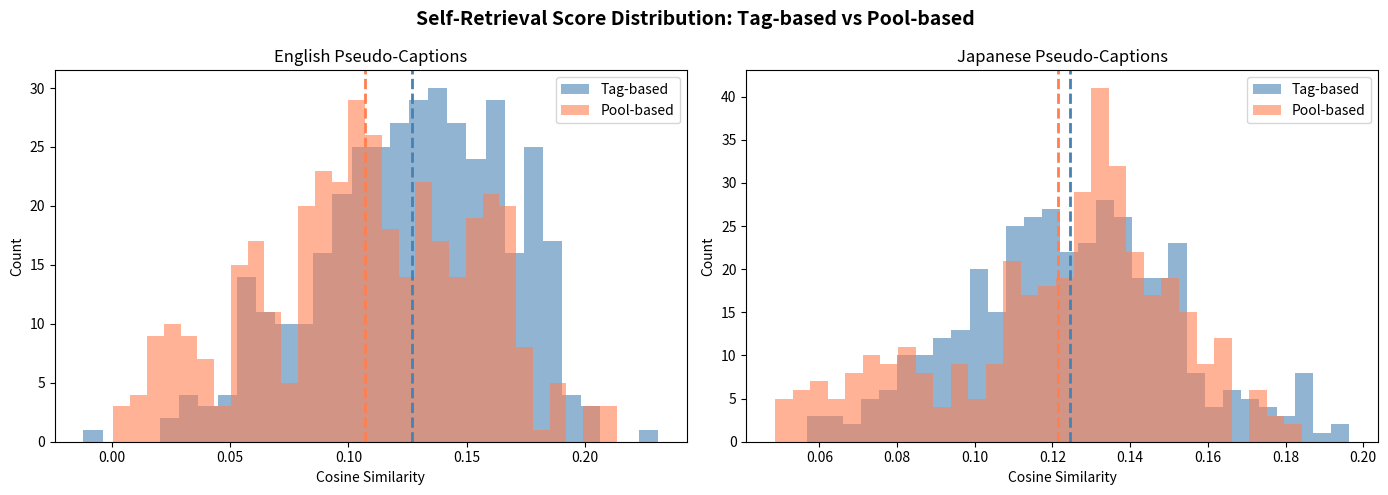

Saved: data/71_self_retrieval_distribution.png


In [17]:
# Self-Retrieval Score の分布比較
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 英語
ax = axes[0]
ax.hist(self_retrieval_en, bins=30, alpha=0.6, label='Tag-based', color='steelblue')
ax.hist(best_caption_scores_en, bins=30, alpha=0.6, label='Pool-based', color='coral')
ax.axvline(self_retrieval_en.mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(best_caption_scores_en.mean(), color='coral', linestyle='--', linewidth=2)
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title('English Pseudo-Captions')
ax.legend()

# 日本語
ax = axes[1]
ax.hist(self_retrieval_ja, bins=30, alpha=0.6, label='Tag-based', color='steelblue')
ax.hist(best_caption_scores_ja, bins=30, alpha=0.6, label='Pool-based', color='coral')
ax.axvline(self_retrieval_ja.mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(best_caption_scores_ja.mean(), color='coral', linestyle='--', linewidth=2)
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title('Japanese Pseudo-Captions')
ax.legend()

plt.suptitle('Self-Retrieval Score Distribution: Tag-based vs Pool-based', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/71_self_retrieval_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/71_self_retrieval_distribution.png")

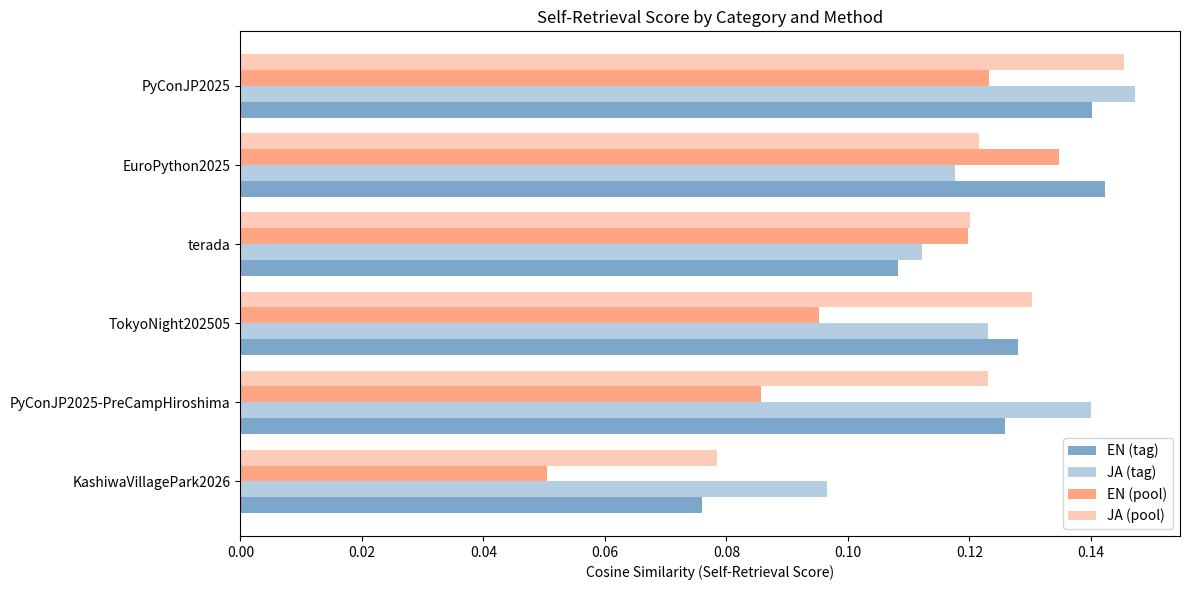

Saved: data/71_self_retrieval_by_category.png


In [18]:
# カテゴリ別の Self-Retrieval Score 比較
fig, ax = plt.subplots(figsize=(12, 6))

categories_sorted = comparison_df.sort_values('Mean (pool)', ascending=True).index
x = np.arange(len(categories_sorted))
width = 0.2

ax.barh(x - 1.5*width, comparison_df.loc[categories_sorted, 'EN (tag)'], width, label='EN (tag)', color='steelblue', alpha=0.7)
ax.barh(x - 0.5*width, comparison_df.loc[categories_sorted, 'JA (tag)'], width, label='JA (tag)', color='steelblue', alpha=0.4)
ax.barh(x + 0.5*width, comparison_df.loc[categories_sorted, 'EN (pool)'], width, label='EN (pool)', color='coral', alpha=0.7)
ax.barh(x + 1.5*width, comparison_df.loc[categories_sorted, 'JA (pool)'], width, label='JA (pool)', color='coral', alpha=0.4)

ax.set_yticks(x)
ax.set_yticklabels(categories_sorted)
ax.set_xlabel('Cosine Similarity (Self-Retrieval Score)')
ax.set_title('Self-Retrieval Score by Category and Method')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../data/71_self_retrieval_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/71_self_retrieval_by_category.png")

Visual Comparison: Image vs Pseudo-Captions


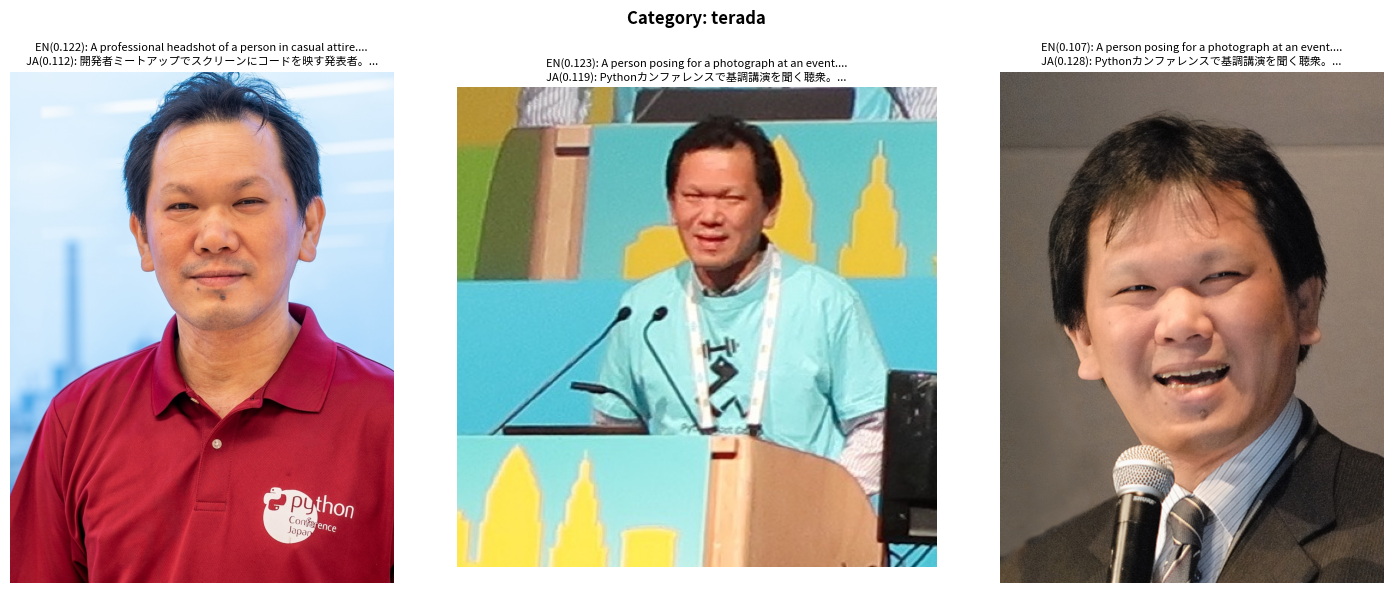

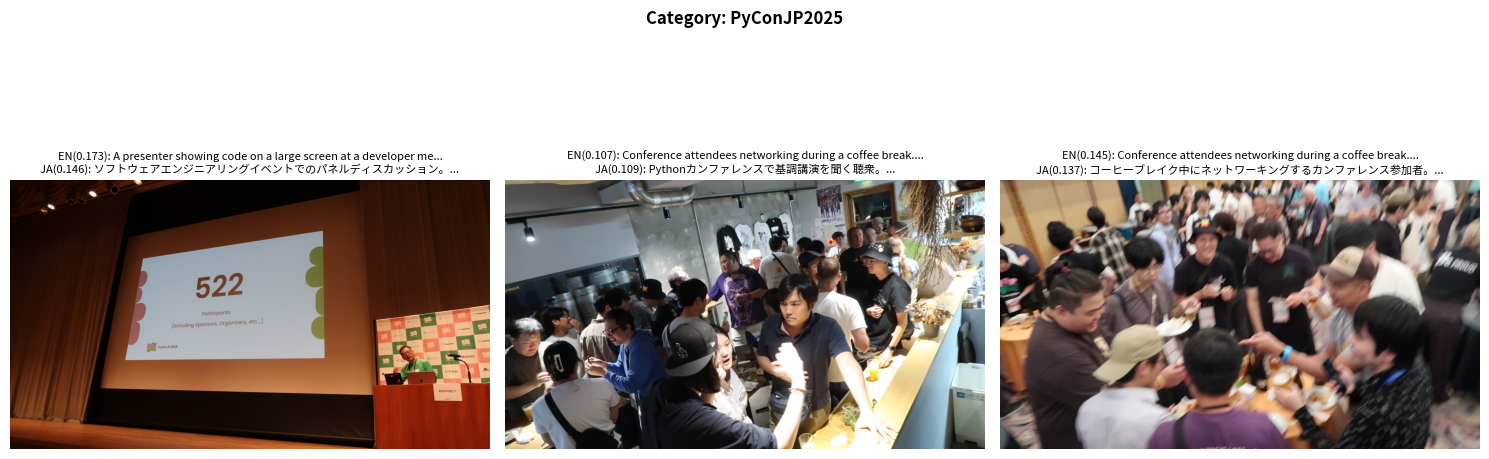

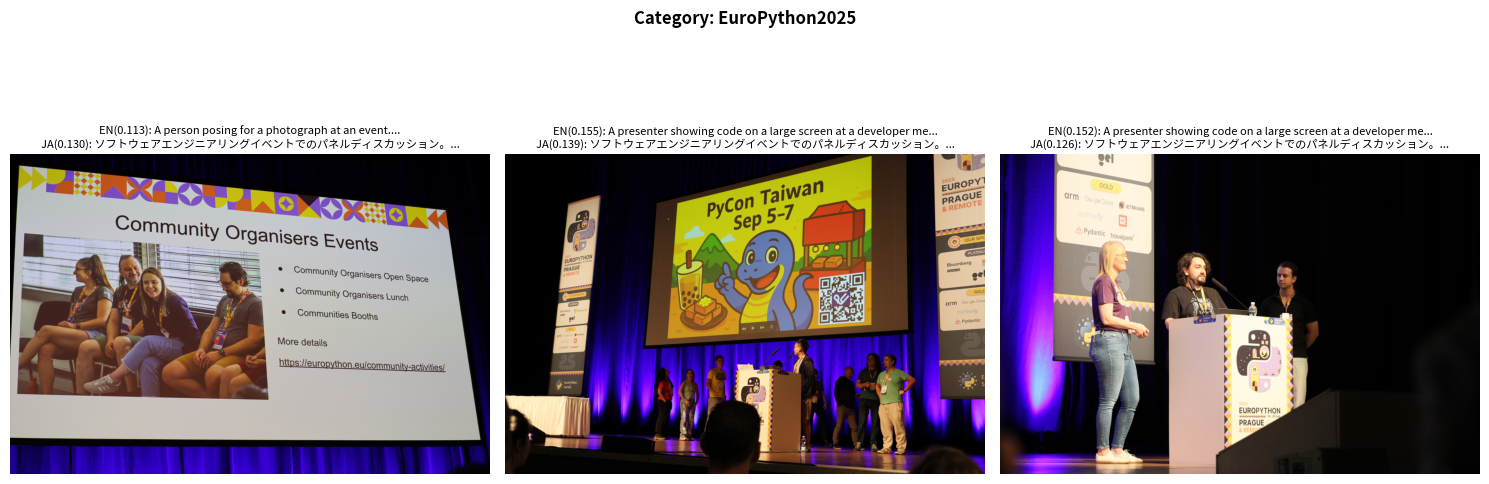

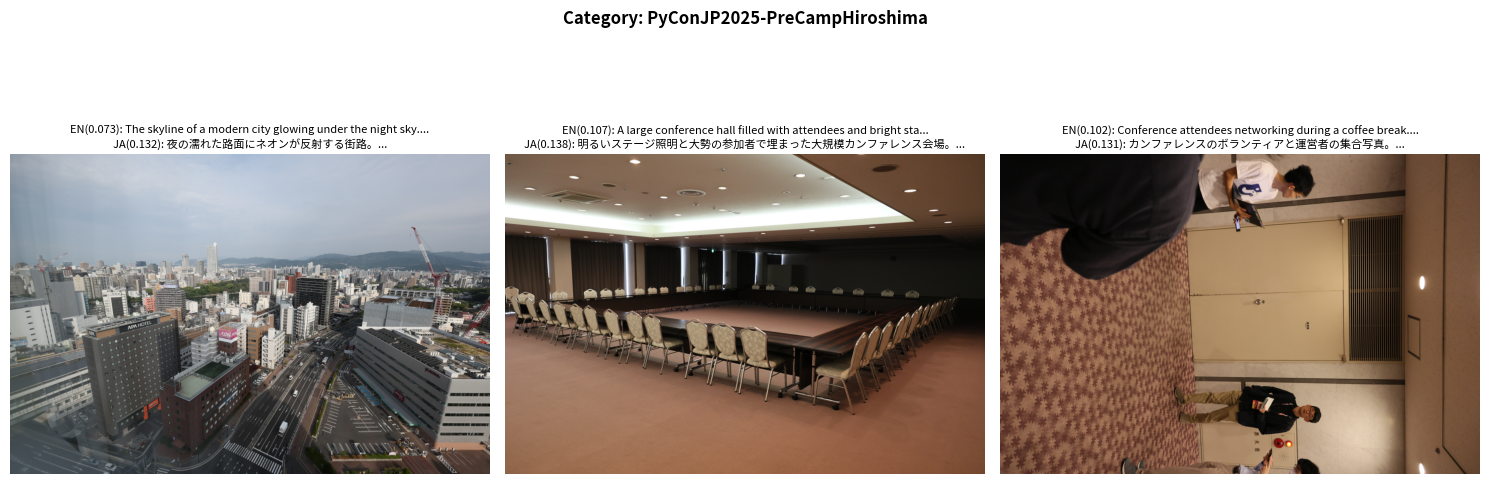

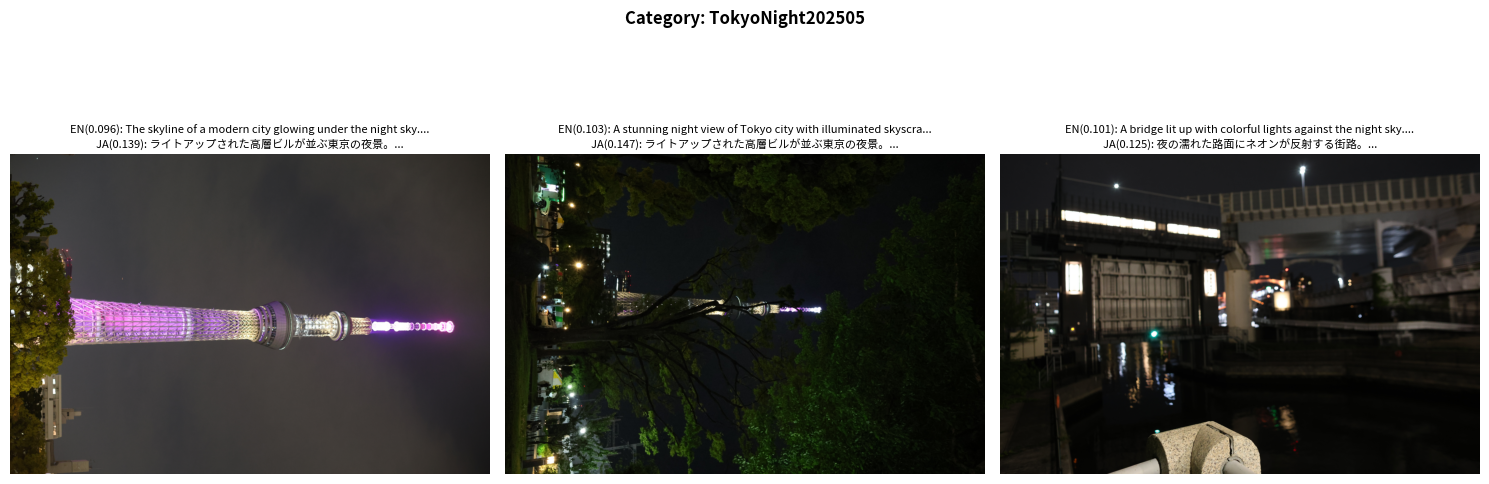

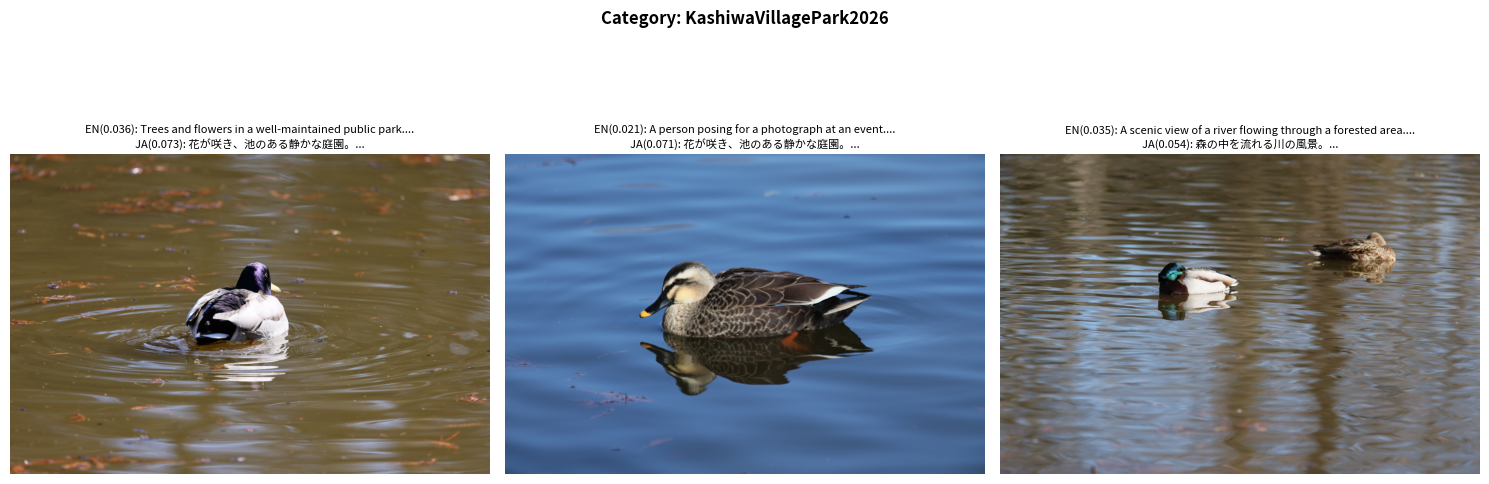

In [19]:
# 画像とキャプションの視覚的確認
print("=" * 80)
print("Visual Comparison: Image vs Pseudo-Captions")
print("=" * 80)

for cat in catalog_df['category'].unique():
    cat_indices = catalog_df[catalog_df['category'] == cat].index.tolist()[:3]
    
    fig, axes = plt.subplots(1, len(cat_indices), figsize=(5 * len(cat_indices), 6))
    if len(cat_indices) == 1:
        axes = [axes]
    
    for i, idx in enumerate(cat_indices):
        row = catalog_df.iloc[idx]
        try:
            img = Image.open(row['file_path'])
            axes[i].imshow(img)
        except Exception:
            axes[i].text(0.5, 0.5, 'Image not found', ha='center', va='center')
        
        # タイトルにキャプション情報
        en_cap = pool_captions_en[idx][:60]
        ja_cap = pool_captions_ja[idx][:40]
        score_en = best_caption_scores_en[idx]
        score_ja = best_caption_scores_ja[idx]
        
        title = f"EN({score_en:.3f}): {en_cap}...\nJA({score_ja:.3f}): {ja_cap}..."
        axes[i].set_title(title, fontsize=8, wrap=True)
        axes[i].axis('off')
    
    plt.suptitle(f'Category: {cat}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

## 7. Retrieval Rank テスト

擬似キャプションで元画像をどのくらいの順位で検索できるかを確認する。
キャプションをクエリとして全画像に対して検索し、元画像が何位に来るかを測定する。

In [20]:
# Retrieval Rank テスト: キャプション→元画像の検索順位
print("Computing retrieval ranks...")

# Pool-based キャプションのembeddingを使用
pool_emb_en = np.array([candidate_emb_en[i] for i in best_caption_idx_en])
pool_emb_ja = np.array([candidate_emb_ja[i] for i in best_caption_idx_ja])

# 全画像に対する類似度行列: (n_images, n_images)
sim_caption_to_image_en = np.dot(pool_emb_en, image_embeddings_norm.T)
sim_caption_to_image_ja = np.dot(pool_emb_ja, image_embeddings_norm.T)

# 各画像について、キャプション→全画像検索で元画像が何位に来るか
ranks_en = []
ranks_ja = []

for i in range(len(catalog_df)):
    sorted_indices_en = np.argsort(sim_caption_to_image_en[i])[::-1]
    sorted_indices_ja = np.argsort(sim_caption_to_image_ja[i])[::-1]
    
    rank_en = np.where(sorted_indices_en == i)[0][0] + 1  # 1-indexed
    rank_ja = np.where(sorted_indices_ja == i)[0][0] + 1
    
    ranks_en.append(rank_en)
    ranks_ja.append(rank_ja)

ranks_en = np.array(ranks_en)
ranks_ja = np.array(ranks_ja)

print("\n" + "=" * 60)
print("Retrieval Rank (Caption → Original Image)")
print("=" * 60)

for lang, ranks in [("EN", ranks_en), ("JA", ranks_ja)]:
    print(f"\n{lang}:")
    print(f"  Mean Rank:    {ranks.mean():.1f} / {len(catalog_df)}")
    print(f"  Median Rank:  {np.median(ranks):.0f}")
    print(f"  Rank@1 (exact match): {(ranks == 1).sum()} / {len(catalog_df)} ({(ranks == 1).mean()*100:.1f}%)")
    print(f"  Rank<=5:  {(ranks <= 5).sum()} / {len(catalog_df)} ({(ranks <= 5).mean()*100:.1f}%)")
    print(f"  Rank<=10: {(ranks <= 10).sum()} / {len(catalog_df)} ({(ranks <= 10).mean()*100:.1f}%)")
    print(f"  MRR: {(1.0 / ranks).mean():.4f}")

Computing retrieval ranks...

Retrieval Rank (Caption → Original Image)

EN:
  Mean Rank:    54.8 / 378
  Median Rank:  27
  Rank@1 (exact match): 14 / 378 (3.7%)
  Rank<=5:  58 / 378 (15.3%)
  Rank<=10: 92 / 378 (24.3%)
  MRR: 0.1102

JA:
  Mean Rank:    75.0 / 378
  Median Rank:  49
  Rank@1 (exact match): 11 / 378 (2.9%)
  Rank<=5:  38 / 378 (10.1%)
  Rank<=10: 72 / 378 (19.0%)
  MRR: 0.0862


In [21]:
# カテゴリ別の Retrieval Rank
rank_df = pd.DataFrame({
    'category': catalog_df['category'],
    'rank_en': ranks_en,
    'rank_ja': ranks_ja,
})

print("\n" + "=" * 80)
print("Retrieval Rank by Category")
print("=" * 80)

for cat in catalog_df['category'].unique():
    cat_data = rank_df[rank_df['category'] == cat]
    print(f"\n{cat} ({len(cat_data)} images):")
    print(f"  EN — Mean Rank: {cat_data['rank_en'].mean():.1f}, MRR: {(1.0/cat_data['rank_en']).mean():.4f}, Rank@1: {(cat_data['rank_en']==1).sum()}")
    print(f"  JA — Mean Rank: {cat_data['rank_ja'].mean():.1f}, MRR: {(1.0/cat_data['rank_ja']).mean():.4f}, Rank@1: {(cat_data['rank_ja']==1).sum()}")


Retrieval Rank by Category

terada (10 images):
  EN — Mean Rank: 27.6, MRR: 0.2375, Rank@1: 1
  JA — Mean Rank: 92.8, MRR: 0.1098, Rank@1: 1

PyConJP2025 (77 images):
  EN — Mean Rank: 48.8, MRR: 0.0912, Rank@1: 2
  JA — Mean Rank: 33.4, MRR: 0.1505, Rank@1: 5

EuroPython2025 (129 images):
  EN — Mean Rank: 48.5, MRR: 0.1094, Rank@1: 6
  JA — Mean Rank: 108.5, MRR: 0.0194, Rank@1: 0

PyConJP2025-PreCampHiroshima (57 images):
  EN — Mean Rank: 79.9, MRR: 0.0941, Rank@1: 1
  JA — Mean Rank: 52.7, MRR: 0.0754, Rank@1: 0

TokyoNight202505 (49 images):
  EN — Mean Rank: 25.3, MRR: 0.1493, Rank@1: 2
  JA — Mean Rank: 28.4, MRR: 0.1846, Rank@1: 3

KashiwaVillagePark2026 (56 images):
  EN — Mean Rank: 82.3, MRR: 0.0974, Rank@1: 2
  JA — Mean Rank: 115.4, MRR: 0.0726, Rank@1: 2


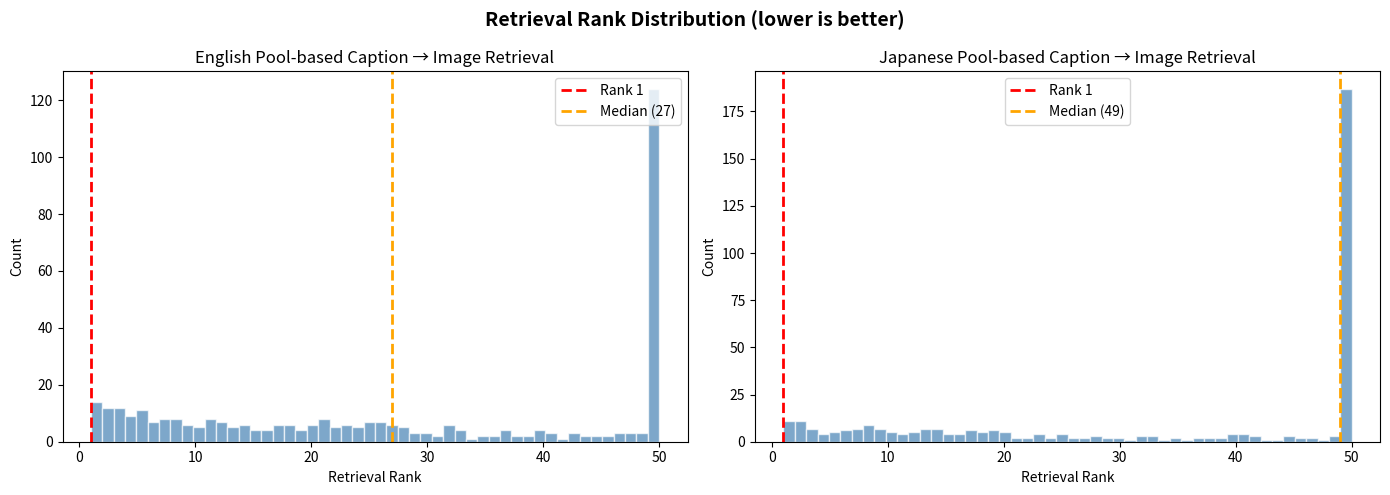

Saved: data/71_retrieval_rank_distribution.png


In [22]:
# Retrieval Rank の分布可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lang, ranks in [(axes[0], 'English', ranks_en), (axes[1], 'Japanese', ranks_ja)]:
    # ランクの分布（上位50位まで）
    clipped = np.clip(ranks, 1, 50)
    ax.hist(clipped, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(1, color='red', linestyle='--', linewidth=2, label='Rank 1')
    ax.axvline(np.median(ranks), color='orange', linestyle='--', linewidth=2,
               label=f'Median ({np.median(ranks):.0f})')
    ax.set_xlabel('Retrieval Rank')
    ax.set_ylabel('Count')
    ax.set_title(f'{lang} Pool-based Caption → Image Retrieval')
    ax.legend()

plt.suptitle('Retrieval Rank Distribution (lower is better)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/71_retrieval_rank_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/71_retrieval_rank_distribution.png")

## 8. 結果の保存

In [23]:
output_data = {
    "notebook": "71-retrieval-based-captioning",
    "model_name": MODEL_NAME,
    "timestamp": datetime.now().isoformat(),
    "total_images": len(catalog_df),
    "methods": {
        "tag_based": {
            "self_retrieval_en_mean": float(self_retrieval_en.mean()),
            "self_retrieval_en_std": float(self_retrieval_en.std()),
            "self_retrieval_ja_mean": float(self_retrieval_ja.mean()),
            "self_retrieval_ja_std": float(self_retrieval_ja.std()),
        },
        "pool_based": {
            "self_retrieval_en_mean": float(best_caption_scores_en.mean()),
            "self_retrieval_en_std": float(best_caption_scores_en.std()),
            "self_retrieval_ja_mean": float(best_caption_scores_ja.mean()),
            "self_retrieval_ja_std": float(best_caption_scores_ja.std()),
            "candidate_pool_size_en": len(candidate_captions_en),
            "candidate_pool_size_ja": len(candidate_captions_ja),
        },
    },
    "retrieval_rank": {
        "en": {
            "mean_rank": float(ranks_en.mean()),
            "median_rank": float(np.median(ranks_en)),
            "rank_at_1_ratio": float((ranks_en == 1).mean()),
            "rank_le_5_ratio": float((ranks_en <= 5).mean()),
            "rank_le_10_ratio": float((ranks_en <= 10).mean()),
            "mrr": float((1.0 / ranks_en).mean()),
        },
        "ja": {
            "mean_rank": float(ranks_ja.mean()),
            "median_rank": float(np.median(ranks_ja)),
            "rank_at_1_ratio": float((ranks_ja == 1).mean()),
            "rank_le_5_ratio": float((ranks_ja <= 5).mean()),
            "rank_le_10_ratio": float((ranks_en <= 10).mean()),
            "mrr": float((1.0 / ranks_ja).mean()),
        },
    },
    "category_results": comparison_df.round(4).to_dict(),
}

output_path = Path("../data/evaluations") / f"71_retrieval_captioning_{datetime.now().strftime('%Y-%m-%d')}.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w") as f:
    json.dump(output_data, f, indent=2, ensure_ascii=False)

print(f"Results saved to: {output_path}")

Results saved to: ../data/evaluations/71_retrieval_captioning_2026-02-19.json


## 9. GPU メモリのクリーンアップ

In [24]:
del embedder
del scene_tagger_en, scene_tagger_ja
del object_tagger_en, object_tagger_ja
del attr_tagger_en, attr_tagger_ja

import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared.")

GPU memory cleared.


## まとめ・評価・考察

既存の対照学習モデル（SigLIP 2 Large）を使って、画像からテキストを「近似的に」生成する2つの手法を評価した。

### 実験結果

| 手法 | Self-Retrieval (EN) | Self-Retrieval (JA) | Retrieval MRR (EN) | Retrieval MRR (JA) |
|------|:---:|:---:|:---:|:---:|
| **Tag-based** | 0.1268 | 0.1245 | — | — |
| **Pool-based** | 0.1070 | 0.1214 | 0.1102 | 0.0862 |

### カテゴリ別分析

- **カンファレンス系**（PyConJP2025, EuroPython2025）: Tag-based が比較的高いスコア（SR EN ~0.14）を示す。「ステージ」「聴衆」「プレゼンテーション」等のラベルが該当画像に適合しやすい。
- **自然風景**（KashiwaVillagePark2026）: 全体的にスコアが低い（SR EN 0.076）。自然の多様性（池、花、遊歩道等）をタグの組み合わせで表現するのが難しい。
- **夜景**（TokyoNight202505）: 中程度のスコア。「夜の都市」「街の灯り」等の明確な特徴があるため、タグ付けは比較的正確。
- **ポートレート**（terada）: 画像数が少なく（10枚）、個人の識別には不向き。
- **Pool-based の JA**: EN より若干高いスコアを示すカテゴリが多い。候補キャプションの日本語がより的確だった可能性がある。

### Retrieval Rank テストの分析

- EN MRR 0.110、JA MRR 0.086 と、元画像の検索精度は非常に低い。
- Rank@1（キャプションで元画像が1位）は EN 3.7%、JA 2.9%。
- **候補プールの制限**: 24件の候補から選択するため、同じカテゴリの画像に同じキャプションが割り当てられ、個別の画像を特定できない。

### 考察

1. **対照学習モデルの根本的な限界**
   - CLIP/SigLIP は画像とテキストを共通の埋め込み空間にマッピングする「類似度計算」モデルであり、テキスト**生成**能力は持たない。
   - Zero-shot分類（タグ付け）は可能だが、自然な文章の生成はできない。
   - 候補プールからの選択は「検索」であり「生成」ではないため、プールに含まれない内容は表現不可。

2. **Self-Retrieval Score が 0.10〜0.13 に留まる理由**
   - タグの組み合わせによる擬似キャプションは、画像の意味的内容の一部しか捉えていない。
   - 空間関係（「木の下に人が座っている」等）や文脈情報（「Pythonカンファレンス」の雰囲気等）を表現できない。
   - このスコアは後続ノートブック（BLIP-2: 0.161, Qwen2.5-VL 等）のベースライン値となる。

3. **日英間の差異**
   - EN と JA のスコア差は小さい（~0.002）。SigLIP 2 Large のGemma BPEトークナイザーが日本語を適切に処理しているためと考えられる。
   - ただし Retrieval Rank では JA の方が劣位（MRR 0.086 vs EN 0.110）。日本語候補文の多様性が不足している可能性。

4. **結論: 専用の画像キャプション生成モデルが必要**
   - 対照学習モデルだけでは、画像の内容を適切なテキストで表現する能力に大きな限界がある。
   - Self-Retrieval Score 0.10〜0.13 がベースライン。これを超えられるかが生成モデルの評価基準。
   - → Notebook 72 以降で、BLIP-2、Florence-2、Qwen2.5-VL 等の**生成型**（generative）モデルを導入し、本格的なキャプション生成を行う。